# Ablations Analysis

Monitor and analyze document selection ablation experiments:
- **Most Negative (Standard)**: Top-k most negatively influential documents
- **Random**: k random documents
- **Most Positive**: Top-k most positively influential documents
- **Most Absolute**: Top-k by absolute influence magnitude
- **Last-k**: Last k documents in training order

In [1]:
import json
import os
from pathlib import Path
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [2]:
# Configuration
RESULTS_BASE = Path('/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/cifar/results/')

EXPERIMENT_DIRS = {
    'infusion': RESULTS_BASE / 'infusion',  # Reference (same as most negative)
    'ablation_random': RESULTS_BASE / 'ablation_random',
    'ablation_positive': RESULTS_BASE / 'ablation_positive',
    'ablation_absolute': RESULTS_BASE / 'ablation_absolute',
    'ablation_last_k': RESULTS_BASE / 'ablation_last_k',
}

DISPLAY_NAMES = {
    'infusion': 'Negative (Std)',
    'ablation_random': 'Random',
    'ablation_positive': 'Positive',
    'ablation_absolute': 'Absolute',
    'ablation_last_k': 'Last-k',
}

COLORS = {
    'infusion': '#2ecc71',
    'ablation_random': '#3498db',
    'ablation_positive': '#e74c3c',
    'ablation_absolute': '#9b59b6',
    'ablation_last_k': '#f39c12',
}

In [3]:
def load_experiment_log(log_path: Path, latest_run_only: bool = True) -> pd.DataFrame:
    """Load experiment log from JSONL file.
    
    Args:
        log_path: Path to the JSONL log file
        latest_run_only: If True, only load experiments from the most recent run
                        (using run_id field)
    """
    if not log_path.exists():
        return pd.DataFrame()
    
    records = []
    with open(log_path, 'r') as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    
    if not records:
        return pd.DataFrame()
    
    df = pd.DataFrame(records)
    
    if latest_run_only and 'run_id' in df.columns:
        # Filter out NaN/empty run_ids (from old entries without run_id)
        valid_run_ids = df['run_id'].dropna()
        valid_run_ids = valid_run_ids[valid_run_ids != '']
        
        if len(valid_run_ids) > 0:
            # Filter to the latest run_id (lexicographically largest = most recent)
            latest_run = valid_run_ids.max()
            df = df[df['run_id'] == latest_run].copy()
            print(f"  (Filtered to run_id: {latest_run}, {len(df)} samples)")
        elif 'timestamp' in df.columns:
            # Fall through to timestamp-based detection
            pass
    
    if latest_run_only and 'run_id' not in df.columns or (latest_run_only and 'run_id' in df.columns and len(df['run_id'].dropna()) == 0):
        if 'timestamp' in df.columns:
            # Fallback: use timestamp-based detection for old logs without run_id
            df['timestamp_parsed'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp_parsed')
            
            # Find run boundaries (gaps > 1 hour indicate separate runs)
            time_diffs = df['timestamp_parsed'].diff()
            run_boundaries = time_diffs > pd.Timedelta(hours=1)
            df['_run_id'] = run_boundaries.cumsum()
            
            # Keep only the latest run
            latest_run = df['_run_id'].max()
            df = df[df['_run_id'] == latest_run].copy()
            df = df.drop(columns=['timestamp_parsed', '_run_id'])
            
            print(f"  (Filtered by timestamp: {len(df)} samples)")
    
    return df


def load_all_experiments(latest_run_only: bool = True) -> Dict[str, pd.DataFrame]:
    """Load all experiment results.
    
    Args:
        latest_run_only: If True, only load the most recent run for each experiment
    """
    results = {}
    for name, dir_path in EXPERIMENT_DIRS.items():
        log_path = dir_path / 'experiment_log.jsonl'
        df = load_experiment_log(log_path, latest_run_only=latest_run_only)
        if not df.empty:
            df['experiment_type'] = name
            results[name] = df
            print(f"{DISPLAY_NAMES[name]}: {len(df)} samples loaded")
        else:
            print(f"{DISPLAY_NAMES[name]}: No data found")
    return results

In [4]:
# Load experiment data from the LATEST RUN only
# Set latest_run_only=False to load all historical data
print("Loading experiment data (latest run only)...\n")
experiments = load_all_experiments(latest_run_only=True)

if not experiments:
    print("\nNo experiment data found. Run experiments first.")

Loading experiment data (latest run only)...

  (Filtered to run_id: 20260118_155238, 45 samples)
Negative (Std): 45 samples loaded
  (Filtered to run_id: 20260118_155913, 23 samples)
Random: 23 samples loaded
  (Filtered to run_id: 20260118_155928, 25 samples)
Positive: 25 samples loaded
  (Filtered to run_id: 20260118_155926, 24 samples)
Absolute: 24 samples loaded
  (Filtered to run_id: 20260118_155935, 26 samples)
Last-k: 26 samples loaded


## Summary Statistics

In [5]:
def compute_statistics(df: pd.DataFrame) -> Dict:
    """Compute summary statistics for delta_prob."""
    if df.empty or 'delta_prob' not in df.columns:
        return {}
    
    delta = df['delta_prob']
    return {
        'n': len(delta),
        'mean': delta.mean(),
        'std': delta.std(),
        'median': delta.median(),
        'min': delta.min(),
        'max': delta.max(),
        'success_rate': (delta > 0).mean() * 100,
        'q25': delta.quantile(0.25),
        'q75': delta.quantile(0.75),
    }


# Compute statistics for each experiment
stats_summary = []
for name, df in experiments.items():
    s = compute_statistics(df)
    if s:
        s['experiment'] = DISPLAY_NAMES[name]
        stats_summary.append(s)

if stats_summary:
    stats_df = pd.DataFrame(stats_summary)
    stats_df = stats_df.set_index('experiment')
    
    # Sort by mean delta_prob
    stats_df = stats_df.sort_values('mean', ascending=False)
    
    print("\nSummary Statistics for delta_prob (sorted by mean):\n")
    display_cols = ['n', 'mean', 'std', 'median', 'success_rate', 'q25', 'q75']
    print(stats_df[display_cols].round(4).to_string())


Summary Statistics for delta_prob (sorted by mean):

                 n    mean     std  median  success_rate     q25     q75
experiment                                                              
Negative (Std)  45  0.2184  0.2846  0.0778         100.0  0.0045  0.3980
Absolute        24  0.1736  0.2374  0.0190         100.0  0.0011  0.3345
Random          23  0.0872  0.1452  0.0024         100.0  0.0003  0.1263
Last-k          26  0.0660  0.1116  0.0034         100.0  0.0002  0.1174
Positive        25  0.0486  0.1083  0.0006          96.0  0.0001  0.0363


## Box Plot Comparison

/local/user/1483801484/ipykernel_135961/444588826.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


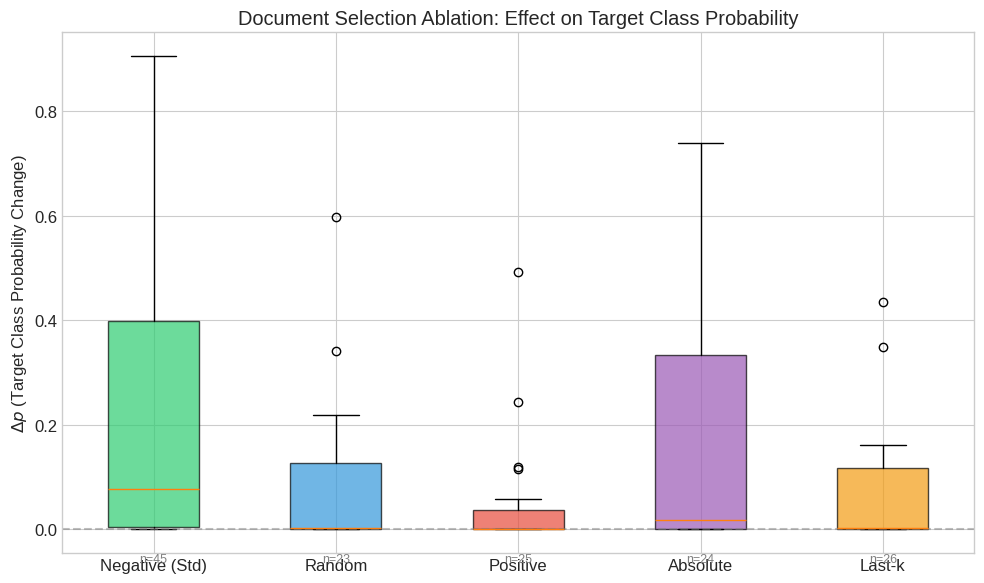

In [6]:
def plot_boxplot(experiments: Dict[str, pd.DataFrame]):
    """Create box plot comparing delta_prob across selection strategies."""
    if not experiments:
        print("No data to plot.")
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data
    data = []
    labels = []
    colors = []
    
    # Order: negative first (reference), then others
    order = ['infusion', 'ablation_random', 'ablation_positive', 'ablation_absolute', 'ablation_last_k']
    
    for name in order:
        if name in experiments and 'delta_prob' in experiments[name].columns:
            data.append(experiments[name]['delta_prob'].values)
            labels.append(DISPLAY_NAMES[name])
            colors.append(COLORS[name])
    
    if not data:
        print("No valid data to plot.")
        return
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('$\\Delta p$ (Target Class Probability Change)')
    ax.set_title('Document Selection Ablation: Effect on Target Class Probability')
    
    # Add sample counts
    for i, (name, d) in enumerate(zip([n for n in order if n in experiments], data)):
        n = len(d)
        ax.annotate(f'n={n}', xy=(i+1, ax.get_ylim()[0]), 
                   ha='center', va='top', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.savefig(RESULTS_BASE / 'ablations_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_boxplot(experiments)

## Strategy Ranking

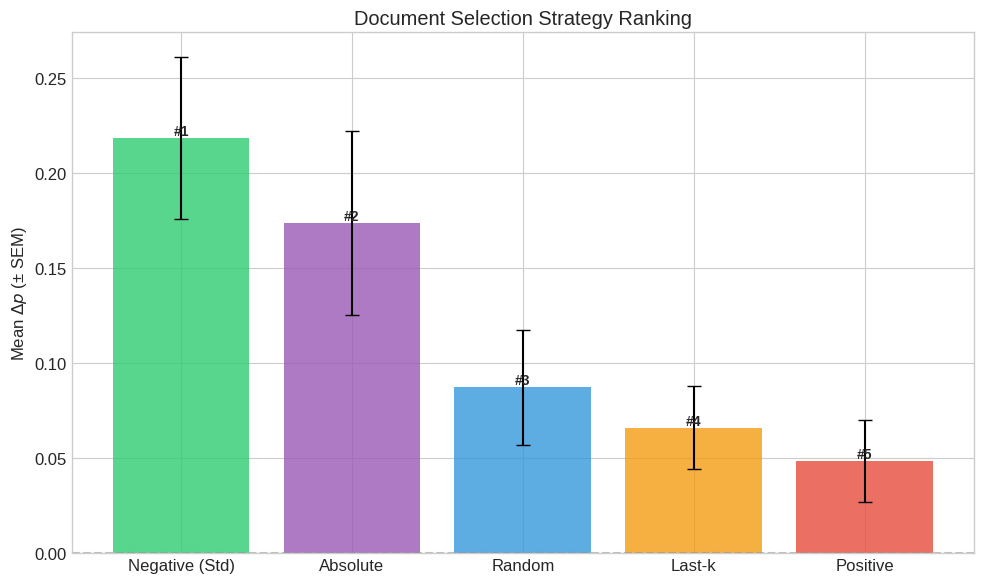

In [7]:
def plot_ranking(experiments: Dict[str, pd.DataFrame]):
    """Bar chart showing mean delta_prob for each strategy, sorted."""
    if not experiments:
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Compute means
    means = {}
    stds = {}
    for name, df in experiments.items():
        if 'delta_prob' in df.columns:
            means[name] = df['delta_prob'].mean()
            stds[name] = df['delta_prob'].std() / np.sqrt(len(df))  # SEM
    
    # Sort by mean
    sorted_names = sorted(means.keys(), key=lambda x: means[x], reverse=True)
    
    names = [DISPLAY_NAMES[n] for n in sorted_names]
    values = [means[n] for n in sorted_names]
    errors = [stds[n] for n in sorted_names]
    bar_colors = [COLORS[n] for n in sorted_names]
    
    bars = ax.bar(names, values, yerr=errors, color=bar_colors, alpha=0.8, capsize=5)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('Mean $\\Delta p$ (± SEM)')
    ax.set_title('Document Selection Strategy Ranking')
    
    # Add rank numbers
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.annotate(f'#{i+1}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(RESULTS_BASE / 'ablations_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_ranking(experiments)

## Statistical Tests

In [8]:
def paired_comparison(experiments: Dict[str, pd.DataFrame], reference: str = 'infusion'):
    """Perform paired t-tests comparing reference to each ablation."""
    if reference not in experiments:
        print(f"Reference experiment '{reference}' not found.")
        return
    
    ref_df = experiments[reference]
    
    print(f"Paired t-tests vs {DISPLAY_NAMES[reference]} (standard Infusion):\n")
    print(f"{'Strategy':<20} {'t-stat':>10} {'p-value':>12} {'Effect Size (d)':>15} {'Significance':>12}")
    print("-" * 70)
    
    for name, df in experiments.items():
        if name == reference:
            continue
        
        # Match samples by index
        if 'sample_idx' in ref_df.columns and 'sample_idx' in df.columns:
            merged = ref_df.merge(df, on=['sample_idx', 'target_class'], suffixes=('_ref', '_test'))
            if len(merged) < 2:
                print(f"{DISPLAY_NAMES[name]:<20} Insufficient paired data")
                continue
            
            ref_vals = merged['delta_prob_ref']
            test_vals = merged['delta_prob_test']
        else:
            # Fallback: use all samples (unpaired)
            ref_vals = ref_df['delta_prob']
            test_vals = df['delta_prob']
        
        # Paired t-test
        t_stat, p_val = stats.ttest_rel(ref_vals, test_vals)
        
        # Cohen's d
        diff = ref_vals - test_vals
        d = diff.mean() / diff.std() if diff.std() > 0 else 0
        
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        
        print(f"{DISPLAY_NAMES[name]:<20} {t_stat:>10.3f} {p_val:>12.4e} {d:>15.3f} {sig:>12}")


if len(experiments) > 1:
    paired_comparison(experiments)

Paired t-tests vs Negative (Std) (standard Infusion):

Strategy                 t-stat      p-value Effect Size (d) Significance
----------------------------------------------------------------------
Random                    3.821   9.3183e-04           0.797          ***
Positive                  3.897   6.8313e-04           0.779          ***
Absolute                  2.119   4.5060e-02           0.433            *
Last-k                    4.082   4.0080e-04           0.801          ***


## Influence Score Analysis

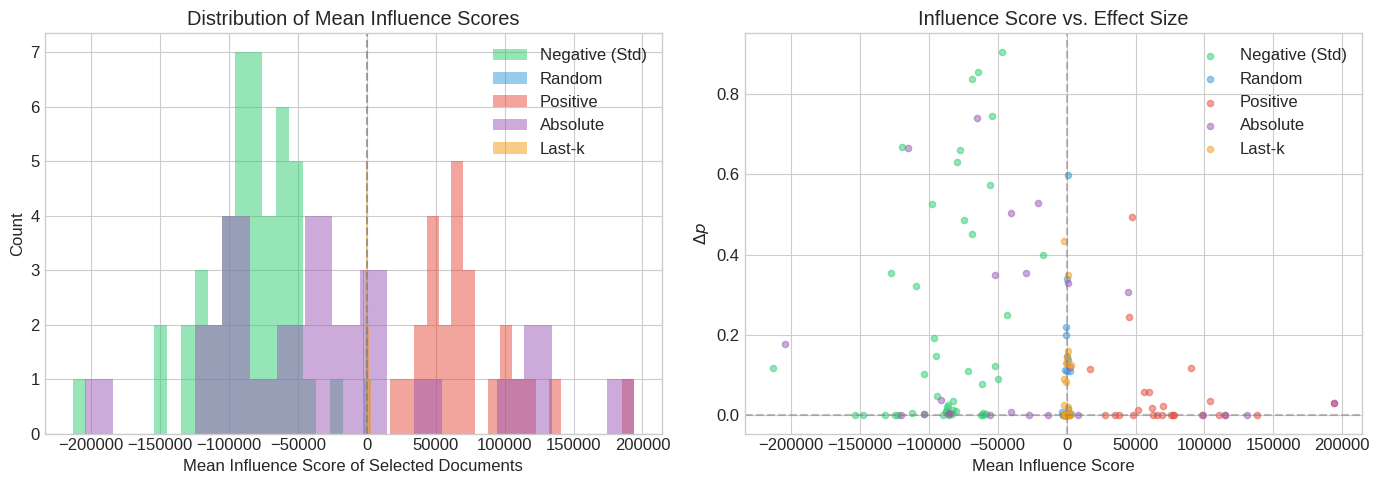

In [9]:
def plot_influence_score_distributions(experiments: Dict[str, pd.DataFrame]):
    """Compare influence score distributions of selected documents."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Mean influence score of selected docs
    ax1 = axes[0]
    order = ['infusion', 'ablation_random', 'ablation_positive', 'ablation_absolute', 'ablation_last_k']
    
    for name in order:
        if name in experiments and 'influence_score_mean' in experiments[name].columns:
            data = experiments[name]['influence_score_mean'].dropna()
            if len(data) > 0:
                ax1.hist(data, bins=20, alpha=0.5, label=DISPLAY_NAMES[name], color=COLORS[name])
    
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
    ax1.set_xlabel('Mean Influence Score of Selected Documents')
    ax1.set_ylabel('Count')
    ax1.set_title('Distribution of Mean Influence Scores')
    ax1.legend()
    
    # Right: Correlation between influence score and delta_prob
    ax2 = axes[1]
    
    for name in order:
        if name in experiments:
            df = experiments[name]
            if 'influence_score_mean' in df.columns and 'delta_prob' in df.columns:
                data = df[['influence_score_mean', 'delta_prob']].dropna()
                if len(data) > 5:
                    ax2.scatter(data['influence_score_mean'], data['delta_prob'], 
                               alpha=0.5, label=DISPLAY_NAMES[name], color=COLORS[name], s=20)
    
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Mean Influence Score')
    ax2.set_ylabel('$\\Delta p$')
    ax2.set_title('Influence Score vs. Effect Size')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(RESULTS_BASE / 'ablations_influence_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_influence_score_distributions(experiments)

## Live Progress Tracking

In [10]:
def show_progress(experiments: Dict[str, pd.DataFrame], expected_n: int = 50):
    """Show experiment progress."""
    print("\nExperiment Progress:\n")
    
    order = ['infusion', 'ablation_random', 'ablation_positive', 'ablation_absolute', 'ablation_last_k']
    
    for name in order:
        if name in experiments:
            n = len(experiments[name])
            pct = n / expected_n * 100
            bar = '=' * int(pct / 5) + ' ' * (20 - int(pct / 5))
            print(f"{DISPLAY_NAMES[name]:<20} [{bar}] {n:>3}/{expected_n} ({pct:.0f}%)")
        else:
            bar = ' ' * 20
            print(f"{DISPLAY_NAMES[name]:<20} [{bar}]   0/{expected_n} (0%)")


show_progress(experiments)


Experiment Progress:

Negative (Std)       [==================  ]  45/50 (90%)
Random               [=========           ]  23/50 (46%)
Positive             [==========          ]  25/50 (50%)
Absolute             [=========           ]  24/50 (48%)
Last-k               [==========          ]  26/50 (52%)
